In [1]:
import pennylane as qml
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython import display
import torchvision
import time
import os

In [2]:
# Quantum Parameters
num_qubits = 8
num_layers = 2
shots = 1000
dev = qml.device("lightning.qubit", wires=num_qubits, shots=shots)

def qcbm_ansatz(params):
    param_idx = 0
    for _ in range(num_layers):
        for qubit in range(num_qubits):
            qml.RX(params[param_idx], wires=qubit)
            param_idx += 1
            qml.RZ(params[param_idx], wires=qubit)
            param_idx += 1
        for i in range(1, num_qubits):
            qml.IsingXX(params[param_idx], wires=[0, i])
            param_idx += 1
        for j in range(1, num_qubits - 1):
            qml.IsingXX(params[param_idx], wires=[j, num_qubits - 1])
            param_idx += 1
        for i in range(1, num_qubits - 1):
            for j in range(i + 1, num_qubits - 1):
                qml.IsingXX(params[param_idx], wires=[i, j])
                param_idx += 1
        for j in range(1, num_qubits - 1):
            qml.IsingXX(params[param_idx], wires=[0, j])
            param_idx += 1
        for i in range(1, num_qubits - 1):
            qml.IsingXX(params[param_idx], wires=[i, num_qubits - 1])
            param_idx += 1
        qml.IsingXX(params[param_idx], wires=[0, num_qubits - 1])
        param_idx += 1
        qml.Barrier()

@qml.qnode(dev, interface='torch')
def circuit(params, basis="computational"):
    qcbm_ansatz(params)
    if basis == "Y":
        for qubit in range(num_qubits):
            qml.RX(np.pi / 2, wires=qubit)
    return qml.probs(wires=range(num_qubits))


In [3]:
# --- Classical GAN models ---
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Linear(latent_dim, 1152),
            nn.BatchNorm1d(1152),
            nn.LeakyReLU()
        )
        self.layer2 = nn.Sequential(
            nn.ConvTranspose2d(1152, 128, kernel_size=3, stride=1, padding=0),
            nn.BatchNorm2d(128),
            nn.LeakyReLU()
        )
        self.layer3 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=0),
            nn.BatchNorm2d(64),
            nn.LeakyReLU()
        )
        self.layer4 = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU()
        )
        self.layer5 = nn.Sequential(
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )
    def forward(self, z):
        z = self.layer1(z)
        z = z.view(-1, 1152, 1, 1)
        z = self.layer2(z)
        z = self.layer3(z)
        z = self.layer4(z)
        z = self.layer5(z)
        return z

class Discriminator(nn.Module):
    def __init__(self, latent_dim):
        super(Discriminator, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU()
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU()
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU()
        )
        self.layer4 = nn.Sequential(
            nn.Conv2d(128, 1152, kernel_size=3, stride=1, padding=0),
            nn.BatchNorm2d(1152),
            nn.LeakyReLU()
        )
        self.output_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1152, latent_dim),
            nn.LeakyReLU(),
            nn.Linear(latent_dim, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        x = x.view(-1, 1, 28, 28)
        x = self.layer1(x)
        x = nn.functional.dropout(x, 0.085)
        x = self.layer2(x)
        x = nn.functional.dropout(x, 0.085)
        x = self.layer3(x)
        x = nn.functional.dropout(x, 0.085)
        x = self.layer4(x)
        x = nn.functional.dropout(x, 0.085)
        x = self.output_layers(x)
        return x

In [4]:
# --- Small CNN Classifier for MNIST Inception Score ---
import torch.nn.functional as F

class SmallMNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, 1)
        self.conv2 = nn.Conv2d(16, 32, 3, 1)
        self.fc1 = nn.Linear(4608, 64)
        self.fc2 = nn.Linear(64, 10)
    def forward(self, x):
        x = x.view(-1, 1, 28, 28)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate and load the classifier
is_classifier = SmallMNISTClassifier()
is_classifier.load_state_dict(torch.load("models/small_mnist_classifier.pth"))
is_classifier.eval()

# --- Custom Inception Score function for MNIST ---
def compute_inception_score(probs, splits=10):
    N = probs.shape[0]
    split_size = N // splits
    scores = []
    for k in range(splits):
        part = probs[k * split_size: (k + 1) * split_size]
        py = torch.mean(part, dim=0)
        kl = part * (torch.log(part + 1e-10) - torch.log(py + 1e-10))
        kl = torch.sum(kl, dim=1)
        scores.append(torch.exp(torch.mean(kl)))
    return torch.mean(torch.tensor(scores)).item()

/var/folders/xl/4k06phkd0zq_dzht7nr6yvmr0000gn/T/ipykernel_87038/3698083064.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  is_classifier.load_state_dict(torch.load("mo

In [5]:
# Setup GAN
latent_dim = 2 ** num_qubits
epochs = 10
batch_size = 64
lr = 0.003
qcbm_lr = 0.1
G = Generator(latent_dim)
D = Discriminator(latent_dim)
criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.9))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.9))

# MNIST Data Loader
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
dataset = MNIST(root='./data', train=True, transform=transform, download=True)
subset_size = int(1.00 * len(dataset))
indices = np.random.choice(len(dataset), subset_size, replace=False)
loader = DataLoader(Subset(dataset, indices), batch_size=batch_size, shuffle=True)

# Initialize QCBM parameters explicitly trainable
num_params = num_layers * ((num_qubits**2 + 7*num_qubits - 6) // 2)
qcbm_params = torch.randn(num_params, requires_grad=True)

# Optimizer for QCBM
qcbm_optimizer = optim.Adam([qcbm_params], lr=qcbm_lr)

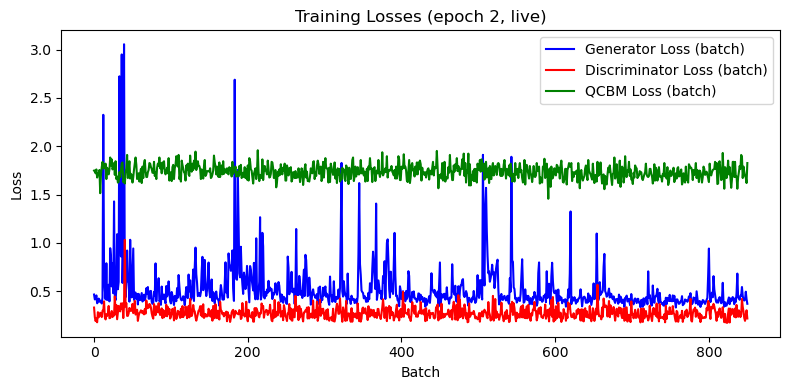

Epoch 2/10:  91%|█████████ | 853/938 [16:22<01:37,  1.15s/it]

In [ ]:
# Live plot setup
plt.ion()
fig, ax = plt.subplots(figsize=(8, 4))

# Hybrid Training Loop
d_losses = []
g_losses = []
qcbm_losses = []
inception_scores = []
os.makedirs("qgan_samples", exist_ok=True)

for epoch in range(epochs):
    epoch_d_loss = 0.0
    epoch_g_loss = 0.0
    epoch_qcbm_loss = 0.0
    num_batches = 0
    # Batch-wise loss lists for live plotting
    batch_d_losses = []
    batch_g_losses = []
    batch_qcbm_losses = []
    for i, (real_imgs, _) in enumerate(tqdm(loader, desc=f'Epoch {epoch+1}/{epochs}')):
        real_imgs = real_imgs.view(-1, 28*28)
        batch_size = real_imgs.size(0)

        # --- Label smoothing and flipping for real and fake labels ---
        real_labels = torch.full((batch_size, 1), 0.9)  # label smoothing: real=0.9
        fake_labels = torch.zeros(batch_size, 1)        # fake=0.0
        # Randomly flip 3% of the labels
        flip_idx = torch.rand(batch_size) < 0.03
        real_labels[flip_idx] = 0.0
        fake_labels[flip_idx] = 0.9

        # Train Discriminator
        optimizer_D.zero_grad()
        z_noise = torch.randn(batch_size, latent_dim)
        fake_imgs = G(z_noise).detach()
        real_validity = D(real_imgs)
        fake_validity = D(fake_imgs)
        d_loss = (criterion(real_validity, real_labels) + criterion(fake_validity, fake_labels)) / 2
        d_loss.backward()
        optimizer_D.step()
        epoch_d_loss += d_loss.item()
        batch_d_losses.append(d_loss.item())

        # Train QCBM to match GAN's latent distribution
        latent_target = torch.mean(real_validity.detach(), dim=0)
        latent_target = torch.softmax(latent_target, dim=0)

        qcbm_optimizer.zero_grad()
        generated_probs = circuit(qcbm_params)
        if generated_probs.shape != latent_target.shape:
            min_len = min(generated_probs.shape[0], latent_target.shape[0])
            generated_probs = generated_probs[:min_len]
            latent_target = latent_target[:min_len]
        loss_qcbm = torch.sum(latent_target * torch.log((latent_target + 1e-8) / (generated_probs + 1e-8)))
        loss_qcbm.backward()
        qcbm_optimizer.step()
        epoch_qcbm_loss += loss_qcbm.item()
        batch_qcbm_losses.append(loss_qcbm.item())

        # Generate quantum-informed priors (one-hot encoding)
        with torch.no_grad():
            q_probs = circuit(qcbm_params).detach().cpu().numpy()
            q_samples = np.random.choice(np.arange(latent_dim), p=q_probs, size=batch_size)
            q_prior = np.zeros((batch_size, latent_dim), dtype=np.float32)
            q_prior[np.arange(batch_size), q_samples] = 1
            q_prior = torch.tensor(q_prior)

        # Train Generator with QCBM-informed prior
        optimizer_G.zero_grad()
        generated_imgs = G(q_prior)
        validity = D(generated_imgs)
        g_loss = criterion(validity, real_labels)  # Use same real_labels (smoothed/flipped) for generator
        g_loss.backward()
        optimizer_G.step()
        epoch_g_loss += g_loss.item()
        batch_g_losses.append(g_loss.item())
        num_batches += 1

        # Live plot update every 20 batches
        if i % 20 == 0:
            ax.clear()
            ax.plot(batch_g_losses, label='Generator Loss (batch)', color='blue')
            ax.plot(batch_d_losses, label='Discriminator Loss (batch)', color='red')
            ax.plot(batch_qcbm_losses, label='QCBM Loss (batch)', color='green')
            ax.set_title(f'Training Losses (epoch {epoch+1}, live)')
            ax.set_xlabel('Batch')
            ax.set_ylabel('Loss')
            ax.legend()
            plt.tight_layout()
            display.clear_output(wait=True)
            display.display(fig)

    # At the end of each epoch, generate samples and compute inception score
    with torch.no_grad():
        z = torch.randn(1000, latent_dim)  # Generate 1000 samples for IS
        fake_imgs = G(z)
        fake_imgs = fake_imgs.to(next(is_classifier.parameters()).device)
        logits = is_classifier(fake_imgs)
        probs = torch.softmax(logits, dim=1)
        score = compute_inception_score(probs)
        inception_scores.append(score)

    d_losses.append(epoch_d_loss / num_batches)
    g_losses.append(epoch_g_loss / num_batches)
    qcbm_losses.append(epoch_qcbm_loss / num_batches)
    print(f'Epoch [{epoch+1}/{epochs}] | D_loss: {d_losses[-1]:.4f} | G_loss: {g_losses[-1]:.4f} | QCBM_loss: {qcbm_losses[-1]:.4f} | Inception Score: {score:.4f}')

    # Save generated images to disk (not shown interactively)
    with torch.no_grad():
        z = torch.rand(16, latent_dim)
        samples = G(z).view(-1, 1, 28, 28)
        grid = torchvision.utils.make_grid(samples, normalize=True)
        fig_img, ax_img = plt.subplots(figsize=(4, 4))
        ax_img.imshow(grid.permute(1, 2, 0).numpy())
        ax_img.axis('off')
        ax_img.set_title(f"Generated Samples at Epoch {epoch+1}")
        current_time = time.strftime("%Y%m%d-%H%M%S")
        plt.savefig(f"qgan_samples/generated_epoch_{epoch+1}_at_Time_{current_time}.png")
        plt.close(fig_img)

# Final plot after training
plt.ioff()
ax.clear()
ax.plot(g_losses, label='Generator Loss (epoch avg)', color='blue')
ax.plot(d_losses, label='Discriminator Loss (epoch avg)', color='red')
ax.plot(qcbm_losses, label='QCBM Loss (epoch avg)', color='green')
ax.set_title('Training Losses (per epoch)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

print("Hybrid Quantum-Classical training completed.")